# Proyecto Econometría — Impacto de la apariencia física en los salarios

**Base de datos:** `beauty`, paquete `wooldridge`  
**Tema:** Beauty: impacto/asociación de la apariencia física en los salarios  
**Modelo principal:** salario por hora explicado por apariencia física y controles socioeconómicos/laborales.

In [2]:
# ============================================================
# 0. Dependencias
# ============================================================

paquetes <- c("wooldridge", "dplyr", "ggplot2", "lmtest", "sandwich", "car", "tseries")

instalar <- paquetes[!(paquetes %in% installed.packages()[,"Package"])]

if(length(instalar)) install.packages(instalar)

lapply(paquetes, library, character.only = TRUE)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘pbkrtest’, ‘lme4’, ‘quadprog’, ‘quantmod’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



[[1]]
 [1] "sandwich"   "lmtest"     "zoo"        "ggplot2"    "wooldridge"
 [6] "stats"      "graphics"   "grDevices"  "utils"      "datasets"  
[11] "methods"    "base"      

[[2]]
 [1] "dplyr"      "sandwich"   "lmtest"     "zoo"        "ggplot2"   
 [6] "wooldridge" "stats"      "graphics"   "grDevices"  "utils"     
[11] "datasets"   "methods"    "base"      

[[3]]
 [1] "dplyr"      "sandwich"   "lmtest"     "zoo"        "ggplot2"   
 [6] "wooldridge" "stats"      "graphics"   "grDevices"  "utils"     
[11] "datasets"   "methods"    "base"      

[[4]]
 [1] "dplyr"      "sandwich"   "lmtest"     "zoo"        "ggplot2"   
 [6] "wooldridge" "stats"      "graphics"   "grDevices"  "utils"     
[11] "datasets"   "methods"    "base"      

[[5]]
 [1] "dplyr"      "sandwich"   "lmtest"     "zoo"        "ggplot2"   
 [6] "wooldridge" "stats"      "graphics"   "grDevices"  "utils"     
[11] "datasets"   "methods"    "base"      

[[6]]
 [1] "car"        "carData"    "dplyr"      "sandwich"   "lmtest"    
 [6] "zoo"        "ggplot2"    "wooldridge" "stats"      "graphics"  
[11] "grDevices"  "utils"      "datasets"   "methods"    "base"      

[[7]]
 [1] "tseries"    "car"        "carData"    "dplyr"      "sandwich"  
 [6] "lmtest"     "zoo"        "ggplot2"    "wooldridge" "stats"     
[11] "graphics"   "grDevices"  "utils"      "datasets"   "methods"   
[16] "base"

## 1. Carga de datos y descripción inicial

La base `beauty` proviene del paquete `wooldridge` y corresponde a datos de corte transversal asociados al estudio de Hamermesh y Biddle (1994), *Beauty and the Labor Market*. La unidad de observación es el trabajador/a. La variable dependiente es `wage`, que mide el salario por hora en dólares.

El objetivo del análisis es evaluar si la apariencia física (`looks`) se asocia con diferencias salariales, controlando por educación, experiencia, género, estado civil, raza y afiliación sindical.

In [3]:
# ============================================================
# 1. Datos
# ============================================================

data("beauty")

# Guardamos una copia original antes de limpiar
beauty_original <- beauty

# Estructura general
names(beauty_original)
str(beauty_original)

# Dimensión original
dim(beauty_original)

[1] "wage"     "lwage"    "belavg"   "abvavg"   "exper"    "looks"   
 [7] "union"    "goodhlth" "black"    "female"   "married"  "south"   
[13] "bigcity"  "smllcity" "service"  "expersq"  "educ"

'data.frame':	1260 obs. of  17 variables:
 $ wage    : num  5.73 4.28 7.96 11.57 11.42 ...
 $ lwage   : num  1.75 1.45 2.07 2.45 2.44 ...
 $ belavg  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ abvavg  : int  1 0 1 0 0 0 0 1 0 0 ...
 $ exper   : int  30 28 35 38 27 20 12 5 5 12 ...
 $ looks   : int  4 3 4 3 3 3 3 4 3 3 ...
 $ union   : int  0 0 0 0 0 0 0 1 0 0 ...
 $ goodhlth: int  1 1 1 1 1 0 1 1 1 1 ...
 $ black   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ female  : int  1 1 1 0 0 1 0 0 1 1 ...
 $ married : int  1 1 0 1 1 1 1 0 0 0 ...
 $ south   : int  0 1 0 0 0 0 0 0 0 0 ...
 $ bigcity : int  0 0 0 1 0 1 1 0 0 0 ...
 $ smllcity: int  1 1 1 0 1 0 0 1 0 1 ...
 $ service : int  1 0 0 1 0 0 0 0 0 0 ...
 $ expersq : int  900 784 1225 1444 729 400 144 25 25 144 ...
 $ educ    : int  14 12 10 16 16 12 16 16 16 12 ...
 - attr(*, "time.stamp")= chr "25 Jun 2011 23:03"


[1] 1260   17

### 1.1 Revisión de datos nulos

Antes de estimar el modelo se revisa la presencia de valores perdidos. Si existen observaciones incompletas, se eliminan con `na.omit()` para trabajar con una muestra consistente entre variables.

In [4]:
# Datos nulos por columna
colSums(is.na(beauty_original))

# Total de datos nulos
sum(is.na(beauty_original))

# Limpieza
beauty <- na.omit(beauty_original)

# Comparación antes/después
dim(beauty_original)
dim(beauty)

wage    lwage   belavg   abvavg    exper    looks    union goodhlth 
       0        0        0        0        0        0        0        0 
   black   female  married    south  bigcity smllcity  service  expersq 
       0        0        0        0        0        0        0        0 
    educ 
       0

[1] 0

[1] 1260   17

[1] 1260   17

## 2. Estadística descriptiva y visualizaciones

Esta sección resume las variables centrales del modelo. En particular, interesa observar la distribución del salario (`wage`) y de la apariencia física (`looks`), además de los controles incluidos en la regresión.

In [5]:
# Variables utilizadas en el modelo principal
vars_modelo <- beauty %>%
  select(wage, looks, educ, exper, female, married, black, union)

# Estadísticas descriptivas básicas
summary(vars_modelo)

# Desviaciones estándar para variables continuas
sapply(beauty[, c("wage", "looks", "educ", "exper")], sd)

# Promedios de variables dummy
sapply(beauty[, c("female", "married", "black", "union")], mean)

      wage            looks            educ           exper      
 Min.   : 1.020   Min.   :1.000   Min.   : 5.00   Min.   : 0.00  
 1st Qu.: 3.708   1st Qu.:3.000   1st Qu.:12.00   1st Qu.: 8.00  
 Median : 5.300   Median :3.000   Median :12.00   Median :15.00  
 Mean   : 6.307   Mean   :3.186   Mean   :12.56   Mean   :18.21  
 3rd Qu.: 7.695   3rd Qu.:4.000   3rd Qu.:13.00   3rd Qu.:27.00  
 Max.   :77.720   Max.   :5.000   Max.   :17.00   Max.   :48.00  
     female         married           black             union       
 Min.   :0.000   Min.   :0.0000   Min.   :0.00000   Min.   :0.0000  
 1st Qu.:0.000   1st Qu.:0.0000   1st Qu.:0.00000   1st Qu.:0.0000  
 Median :0.000   Median :1.0000   Median :0.00000   Median :0.0000  
 Mean   :0.346   Mean   :0.6913   Mean   :0.07381   Mean   :0.2722  
 3rd Qu.:1.000   3rd Qu.:1.0000   3rd Qu.:0.00000   3rd Qu.:1.0000  
 Max.   :1.000   Max.   :1.0000   Max.   :1.00000   Max.   :1.0000  

wage      looks       educ      exper 
 4.6606390  0.6848774  2.6244892 11.9634853

female    married      black      union 
0.34603175 0.69126984 0.07380952 0.27222222

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



,wage,looks,educ,exper,female,married,black,union
wage,1.00000000,0.05501909,0.212332819,0.234632213,-0.313419441,0.18452077,-0.059051728,0.09452922
looks,0.05501909,1.00000000,0.153841722,-0.155035004,0.017128517,-0.06463584,0.012098123,-0.04349550
educ,0.21233282,0.15384172,1.000000000,-0.186199948,0.009105143,-0.04767433,-0.138156833,-0.09602178
exper,0.23463221,-0.15503500,-0.186199948,1.000000000,-0.247208714,0.25560693,0.007566461,0.08979243
female,-0.31341944,0.01712852,0.009105143,-0.247208714,1.000000000,-0.31922793,0.113702832,-0.10003741
married,0.18452077,-0.06463584,-0.047674330,0.255606932,-0.319227934,1.00000000,-0.133306412,0.05362856
black,-0.05905173,0.01209812,-0.138156833,0.007566461,0.113702832,-0.13330641,1.000000000,0.03193868
union,0.09452922,-0.04349550,-0.096021780,0.089792433,-0.100037415,0.05362856,0.031938682,1.00000000


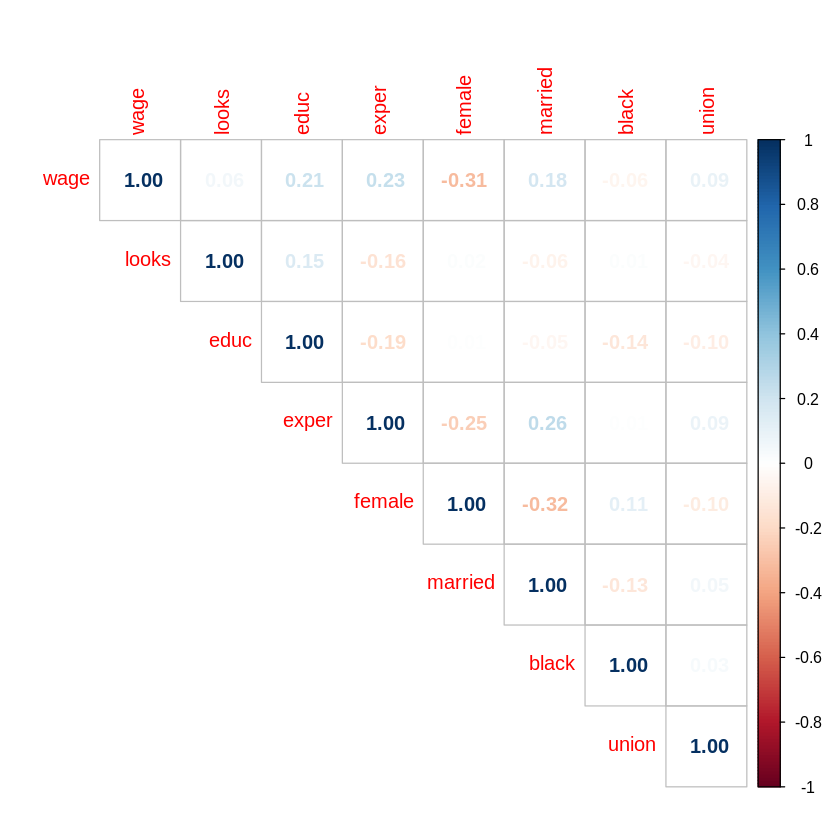

In [7]:
install.packages("corrplot")
library(corrplot)
# Correlaciones entre variables numéricas del modelo
cor(vars_modelo)

# Visualización de correlaciones
corrplot(cor(vars_modelo), method = "number", type = "upper")

### Interpretación descriptiva sugerida

- El salario por hora presenta asimetría positiva: la mayoría de los trabajadores se concentra en salarios relativamente bajos o medios, pero existen valores altos que elevan la media.
- La variable `looks` se concentra principalmente en valores cercanos al promedio, especialmente en el nivel 3.
- Las correlaciones permiten observar relaciones simples entre variables, pero no deben interpretarse como efectos causales, ya que no controlan simultáneamente por otros factores.

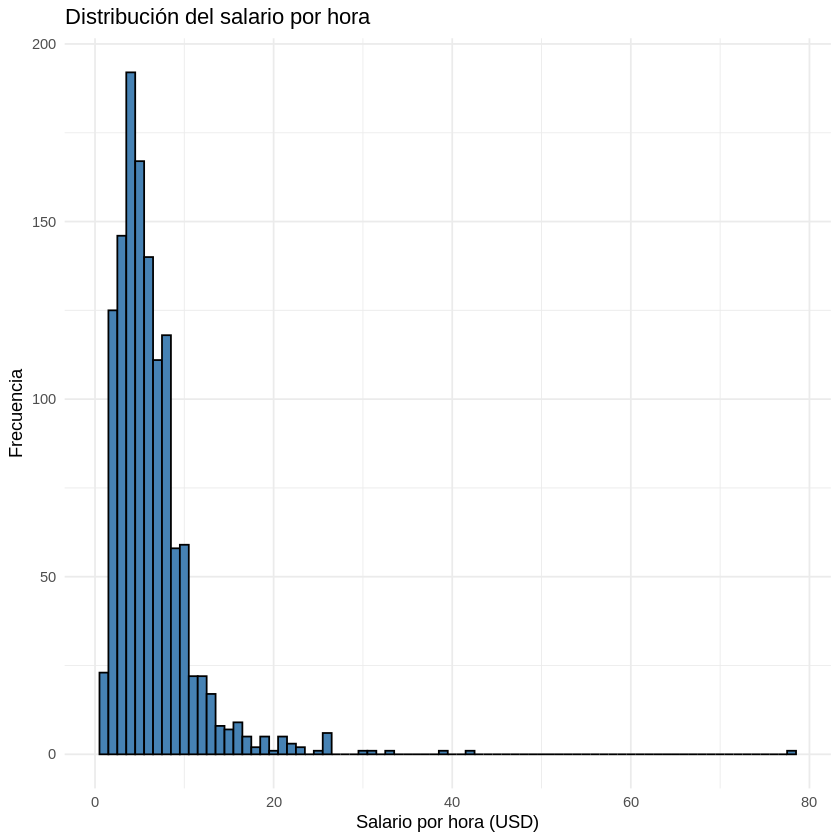

In [8]:
# 2.1 Histograma de salario
ggplot(beauty, aes(x = wage)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "black") +
  labs(title = "Distribución del salario por hora",
       x = "Salario por hora (USD)",
       y = "Frecuencia") +
  theme_minimal()

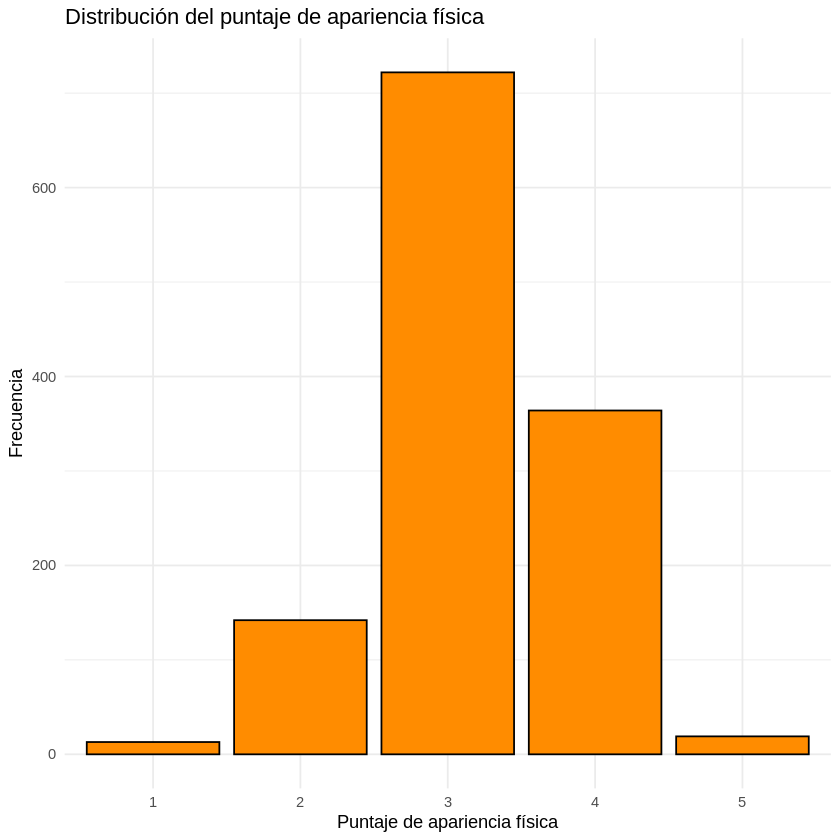

In [9]:
# 2.2 Distribución del puntaje de apariencia
ggplot(beauty, aes(x = factor(looks))) +
  geom_bar(fill = "darkorange", color = "black") +
  labs(title = "Distribución del puntaje de apariencia física",
       x = "Puntaje de apariencia física",
       y = "Frecuencia") +
  theme_minimal()

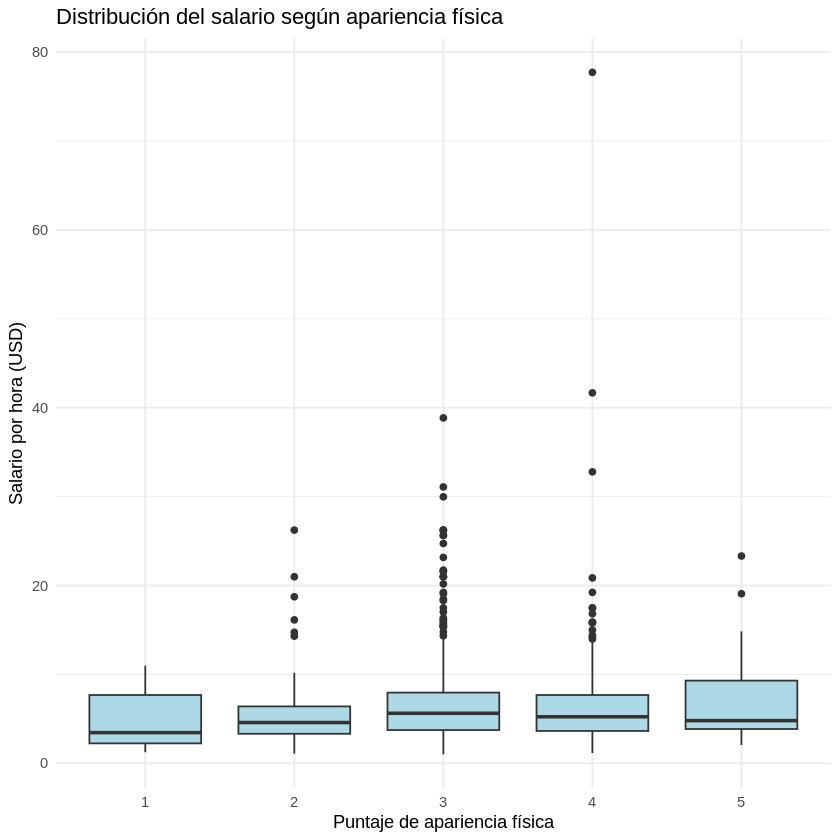

In [10]:
# 2.3 Salario según apariencia física
ggplot(beauty, aes(x = factor(looks), y = wage)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Distribución del salario según apariencia física",
       x = "Puntaje de apariencia física",
       y = "Salario por hora (USD)") +
  theme_minimal()

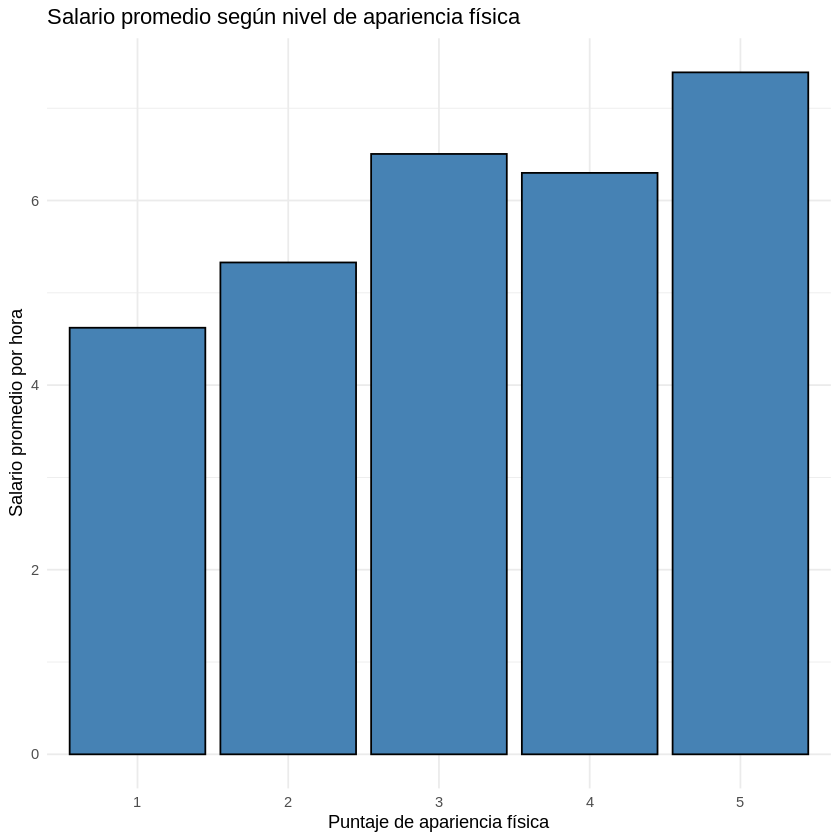

In [11]:
# 2.4 Salario promedio según apariencia física
ggplot(beauty, aes(x = factor(looks), y = wage)) +
  stat_summary(fun = mean, geom = "bar", fill = "steelblue", color = "black") +
  labs(title = "Salario promedio según nivel de apariencia física",
       x = "Puntaje de apariencia física",
       y = "Salario promedio por hora") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


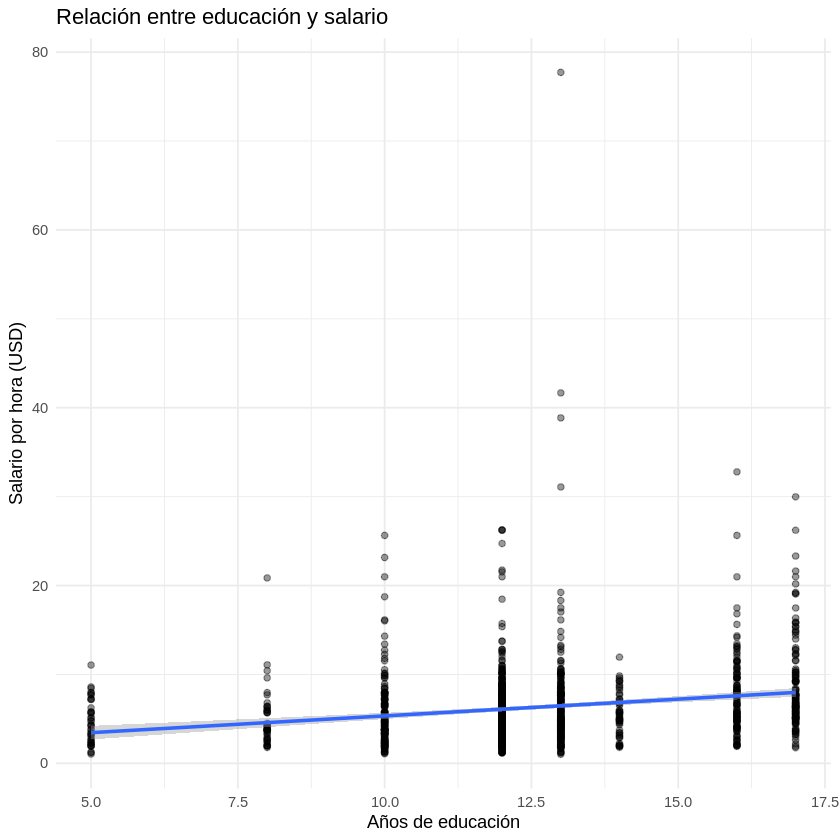

In [12]:
# 2.5 Relación salario-educación
ggplot(beauty, aes(x = educ, y = wage)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(title = "Relación entre educación y salario",
       x = "Años de educación",
       y = "Salario por hora (USD)") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


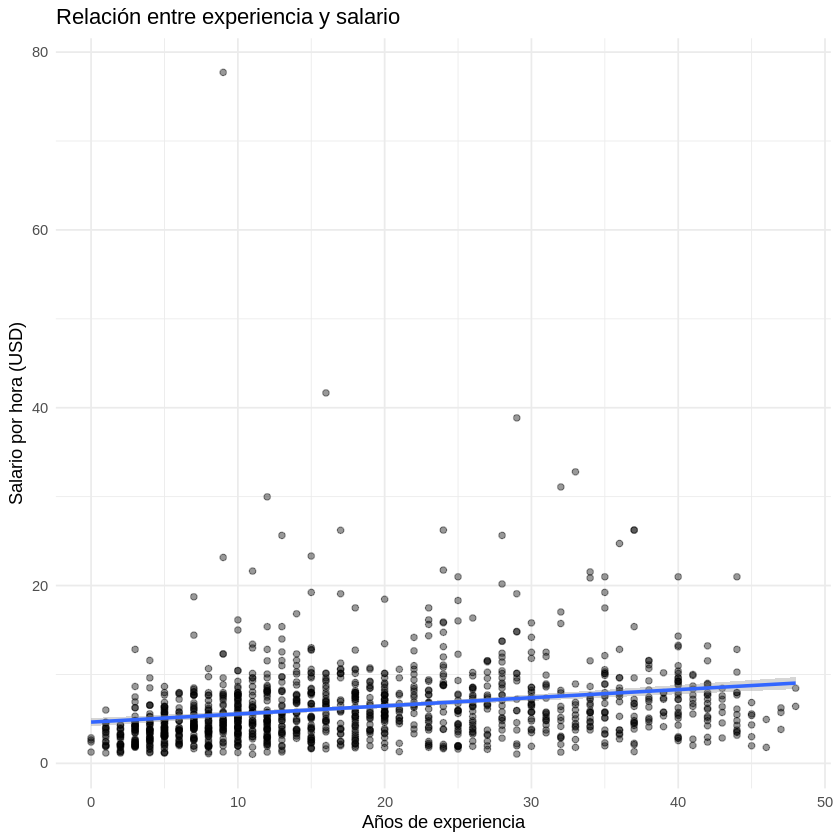

In [13]:
# 2.6 Relación salario-experiencia
ggplot(beauty, aes(x = exper, y = wage)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(title = "Relación entre experiencia y salario",
       x = "Años de experiencia",
       y = "Salario por hora (USD)") +
  theme_minimal()

## 3. Modelo poblacional e hipótesis de investigación

Se propone el siguiente Modelo de Regresión Lineal Múltiple:

$$wage_i = \beta_0 + \beta_1 looks_i + \beta_2 educ_i + \beta_3 exper_i + \beta_4 female_i + \beta_5 married_i + \beta_6 black_i + \beta_7 union_i + u_i$$

La variable dependiente es `wage`, pues el objetivo del trabajo es estudiar diferencias salariales. La variable de interés es `looks`, ya que mide la apariencia física del trabajador/a. Las demás variables se incorporan como controles relevantes del mercado laboral.

### Justificación de variables

- `looks`: variable central del estudio; permite evaluar la existencia de un posible *beauty premium*.
- `educ`: años de educación, relacionada con capital humano.
- `exper`: experiencia laboral, también vinculada al capital humano.
- `female`: controla diferencias salariales por género.
- `married`: captura diferencias asociadas al estado civil.
- `black`: control sociodemográfico.
- `union`: afiliación sindical, asociada al poder de negociación salarial.

### Hipótesis

**H1:** Una mayor apariencia física se asocia positivamente con el salario por hora.  
$$H_0: \beta_{looks}=0 \quad vs. \quad H_1: \beta_{looks}>0$$

**H2:** Más años de educación se asocian positivamente con el salario por hora.  
$$H_0: \beta_{educ}=0 \quad vs. \quad H_1: \beta_{educ}>0$$

**H3:** Ser mujer se asocia negativamente con el salario por hora, controlando por las demás variables.  
$$H_0: \beta_{female}=0 \quad vs. \quad H_1: \beta_{female}<0$$

**H4:** Pertenecer a un sindicato se asocia positivamente con el salario por hora.  
$$H_0: \beta_{union}=0 \quad vs. \quad H_1: \beta_{union}>0$$

In [14]:
# ============================================================
# 3. Estimación del modelo principal
# ============================================================

model <- lm(wage ~ looks + educ + exper + female + married + black + union,
            data = beauty)

summary(model)


Call:
lm(formula = wage ~ looks + educ + exper + female + married + 
    black + union, data = beauty)

Residuals:
   Min     1Q Median     3Q    Max 
-7.320 -2.146 -0.564  1.098 72.234 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.07427    0.87753  -2.364  0.01824 *  
looks        0.40628    0.17583   2.311  0.02101 *  
educ         0.45410    0.04670   9.724  < 2e-16 ***
exper        0.08128    0.01063   7.643 4.19e-14 ***
female      -2.31710    0.26766  -8.657  < 2e-16 ***
married      0.69272    0.27609   2.509  0.01223 *  
black        0.13592    0.46140   0.295  0.76837    
union        0.78868    0.26768   2.946  0.00328 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.18 on 1252 degrees of freedom
Multiple R-squared:    0.2,	Adjusted R-squared:  0.1956 
F-statistic: 44.72 on 7 and 1252 DF,  p-value: < 2.2e-16


## 4. Resultados del modelo principal

La interpretación económica de los coeficientes debe realizarse *ceteris paribus*, es decir, manteniendo constantes las demás variables incluidas en el modelo.

Con los resultados obtenidos:

- `looks`: un punto adicional en apariencia física se asocia con un aumento promedio de aproximadamente 0.406 dólares por hora en el salario, manteniendo constantes las demás variables.
- `educ`: un año adicional de educación se asocia con un aumento promedio de aproximadamente 0.454 dólares por hora.
- `exper`: un año adicional de experiencia se asocia con un aumento promedio de aproximadamente 0.081 dólares por hora.
- `female`: las mujeres ganan en promedio aproximadamente 2.317 dólares menos por hora que los hombres, controlando por las demás variables.
- `married`: las personas casadas presentan un salario promedio mayor que las no casadas, ceteris paribus.
- `black`: el coeficiente no resulta estadísticamente significativo en esta especificación.
- `union`: pertenecer a un sindicato se asocia con un salario promedio mayor.

El $R^2$ del modelo indica la proporción de variabilidad del salario explicada por los regresores. En datos de corte transversal socioeconómicos, valores moderados son habituales, ya que existen muchos factores individuales y laborales no observados que también explican los salarios.

In [15]:
# Tabla ordenada de coeficientes OLS
coefs <- summary(model)$coefficients

tabla_ols <- data.frame(
  Variable = rownames(coefs),
  Estimacion = coefs[, 1],
  Error_Estandar = coefs[, 2],
  t_value = coefs[, 3],
  p_value = coefs[, 4],
  row.names = NULL
)

tabla_ols

Variable,Estimacion,Error_Estandar,t_value,p_value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-2.07427409,0.87752512,-2.3637774,1.824170e-02
looks,0.40627963,0.17582558,2.3106969,2.101147e-02
educ,0.45410300,0.04669866,9.7241122,1.351109e-21
exper,0.08127717,0.01063370,7.6433597,4.192522e-14
female,-2.31709840,0.26766477,-8.6567179,1.469522e-17
married,0.69271973,0.27608926,2.5090426,1.223140e-02
black,0.13591656,0.46139590,0.2945769,7.683660e-01
union,0.78867626,0.26768224,2.9463152,3.275346e-03


## 5. Verificación de supuestos del MRLM

La rúbrica exige verificar exogeneidad, homocedasticidad, normalidad, multicolinealidad y aplicar correcciones si corresponde. Por ello, se evalúan los principales supuestos del modelo.

### 5.1 Exogeneidad

El supuesto de exogeneidad exige:

$$E(u_i \mid X_i)=0$$

Esto significa que los regresores no deben estar correlacionados con el término de error. En este trabajo, la exogeneidad no puede probarse completamente con un test simple, por lo que se discute desde la teoría económica y las limitaciones de la base.

La principal amenaza es el sesgo por variables omitidas. Variables como habilidad, productividad, tipo de ocupación, sector económico, empresa, cargo o redes laborales podrían afectar el salario y estar correlacionadas con algunas variables incluidas, especialmente `looks`, `educ` o `female`. Por esta razón, los resultados se interpretan como asociaciones condicionales y no como causalidad definitiva.

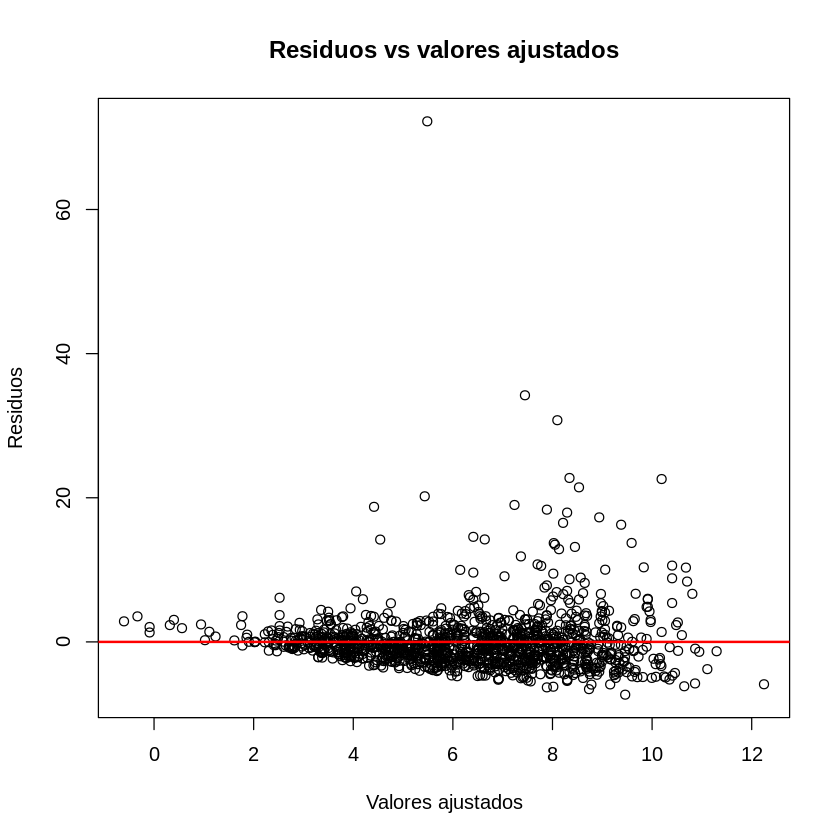

In [16]:
# Residuos del modelo
residuos <- residuals(model)

# Gráfico de residuos vs valores ajustados
plot(fitted(model), residuos,
     main = "Residuos vs valores ajustados",
     xlab = "Valores ajustados",
     ylab = "Residuos")
abline(h = 0, col = "red", lwd = 2)

### 5.2 Homocedasticidad

Se aplican las pruebas de Breusch-Pagan y White. La hipótesis nula en ambas pruebas es homocedasticidad.

- Si el p-valor es menor a 0.05, se rechaza homocedasticidad.
- Si el p-valor es mayor a 0.05, no existe evidencia suficiente para rechazar homocedasticidad.

In [17]:
# Breusch-Pagan
bp <- bptest(model)
bp

# White: versión ampliada con variables, cuadrados e interacciones
white <- bptest(model,
                ~ looks + educ + exper + female + married + black + union +
                  I(looks^2) + I(educ^2) + I(exper^2) +
                  looks:educ + looks:exper + educ:exper,
                data = beauty)
white


	studentized Breusch-Pagan test

data:  model
BP = 16.583, df = 7, p-value = 0.02029



	studentized Breusch-Pagan test

data:  model
BP = 17.893, df = 13, p-value = 0.1616


El test de Breusch-Pagan presenta un p-valor de 0.02029, menor a 0.05, por lo que se rechaza la hipótesis nula de homocedasticidad. Esto entrega evidencia de heterocedasticidad en el modelo.

Por otro lado, el test de White presenta un p-valor de 0.1616, mayor a 0.05, por lo que no se rechaza la hipótesis nula de homocedasticidad. Dado que los resultados son mixtos, se adopta una postura conservadora y se reportan errores estándar robustos HC1.

### 5.3 Corrección por heterocedasticidad: errores estándar robustos HC1

Dado que Breusch-Pagan detecta evidencia de heterocedasticidad, se reportan errores estándar robustos HC1. Esta corrección no cambia los coeficientes estimados, pero sí ajusta los errores estándar, los estadísticos t y los p-valores, haciendo la inferencia más confiable.

In [18]:
# Errores estándar robustos HC1
robusto <- coeftest(model, vcov = vcovHC(model, type = "HC1"))
robusto


t test of coefficients:

              Estimate Std. Error t value  Pr(>|t|)    
(Intercept) -2.0742741  1.0139163 -2.0458  0.040984 *  
looks        0.4062796  0.1713245  2.3714  0.017871 *  
educ         0.4541030  0.0441314 10.2898 < 2.2e-16 ***
exper        0.0812772  0.0098355  8.2637 3.563e-16 ***
female      -2.3170984  0.2514310 -9.2156 < 2.2e-16 ***
married      0.6927197  0.2916452  2.3752  0.017689 *  
black        0.1359166  0.8464054  0.1606  0.872449    
union        0.7886763  0.3024172  2.6079  0.009218 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Al utilizar errores estándar robustos HC1, los coeficientes estimados se mantienen iguales, pero cambian los errores estándar, los estadísticos t y los p-valores. Con esta corrección, `looks` continúa siendo positivo y estadísticamente significativo al 5%, con un p-valor de 0.01787. Por lo tanto, incluso corrigiendo por heterocedasticidad, se mantiene evidencia de una asociación positiva entre apariencia física y salario por hora.

### 5.4 Normalidad de los errores

Se evalúa la normalidad de los residuos mediante Jarque-Bera y QQ-plot. En muestras grandes, la normalidad exacta de los errores no es estrictamente necesaria para la consistencia de MCO, ya que la inferencia se apoya en resultados asintóticos. Sin embargo, una fuerte no normalidad puede indicar presencia de valores extremos o mala especificación.


	Jarque Bera Test

data:  residuos
X-squared = 347264, df = 2, p-value < 2.2e-16


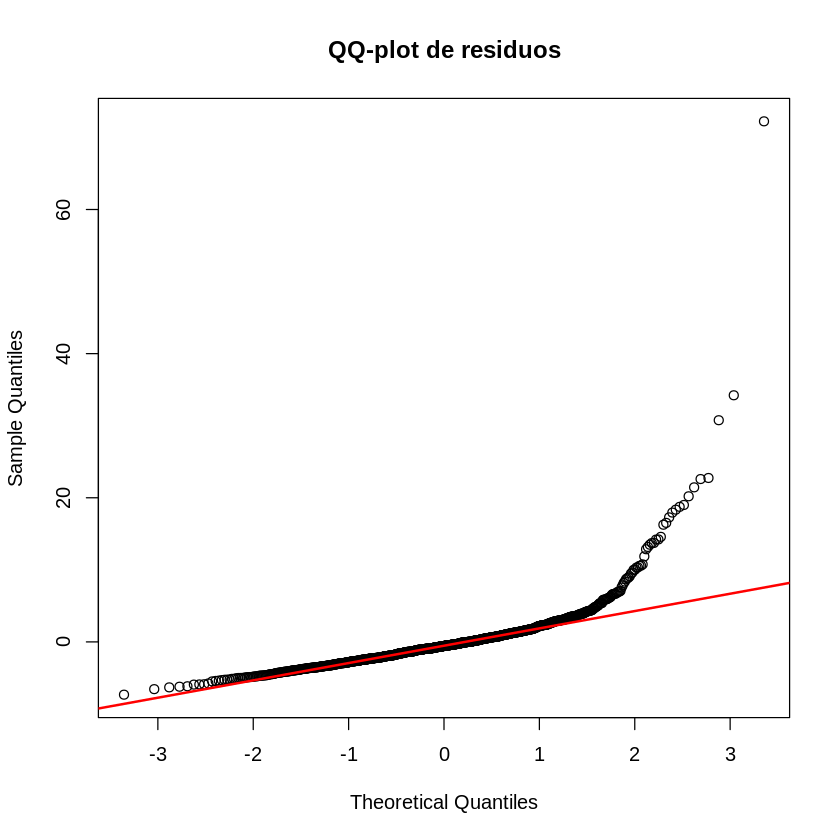

In [19]:
# Jarque-Bera
jarque.bera.test(residuos)

# QQ-plot
qqnorm(residuos, main = "QQ-plot de residuos")
qqline(residuos, col = "red", lwd = 2)

### 5.5 Multicolinealidad

Se calcula el Factor de Inflación de la Varianza (VIF). Como regla práctica, valores mayores a 10 suelen indicar multicolinealidad severa. Valores cercanos a 1 sugieren baja correlación lineal entre regresores.

In [20]:
vifs <- vif(model)
vifs

looks     educ    exper   female  married    black    union 
1.044796 1.082282 1.166073 1.169073 1.173039 1.049414 1.023642

Si todos los VIF son bajos, no existe evidencia de multicolinealidad severa. Por lo tanto, no es necesario eliminar variables por este motivo.

## 6. Testeo de hipótesis de investigación

Las hipótesis se contrastan usando los resultados del modelo corregido con errores estándar robustos HC1, dado que se detectó evidencia de heterocedasticidad en Breusch-Pagan.

In [21]:
# Coeficientes robustos en formato matriz
rob <- coeftest(model, vcov = vcovHC(model, type = "HC1"))

# Grados de libertad del modelo
gl <- model$df.residual

# Extraemos t robustos
t_looks  <- rob["looks", "t value"]
t_educ   <- rob["educ", "t value"]
t_female <- rob["female", "t value"]
t_union  <- rob["union", "t value"]

# Pruebas unilaterales según hipótesis
p_looks_uni  <- pt(t_looks,  df = gl, lower.tail = FALSE) # beta looks > 0
p_educ_uni   <- pt(t_educ,   df = gl, lower.tail = FALSE) # beta educ > 0
p_female_uni <- pt(t_female, df = gl, lower.tail = TRUE)  # beta female < 0
p_union_uni  <- pt(t_union,  df = gl, lower.tail = FALSE) # beta union > 0

tabla_hipotesis <- data.frame(
  Hipotesis = c("H1: beta_looks > 0", "H2: beta_educ > 0",
                "H3: beta_female < 0", "H4: beta_union > 0"),
  t_robusto = c(t_looks, t_educ, t_female, t_union),
  p_valor_unilateral = c(p_looks_uni, p_educ_uni, p_female_uni, p_union_uni),
  Decision_5pct = ifelse(c(p_looks_uni, p_educ_uni, p_female_uni, p_union_uni) < 0.05,
                         "Se rechaza H0", "No se rechaza H0")
)

tabla_hipotesis

Hipotesis,t_robusto,p_valor_unilateral,Decision_5pct
<chr>,<dbl>,<dbl>,<chr>
H1: beta_looks > 0,2.371404,8.935626e-03,Se rechaza H0
H2: beta_educ > 0,10.289800,3.397225e-24,Se rechaza H0
H3: beta_female < 0,-9.215645,6.342412e-20,Se rechaza H0
H4: beta_union > 0,2.607908,4.609062e-03,Se rechaza H0


## 7. Modelo alternativo de robustez: salario en logaritmo

Dado que el salario presenta asimetría positiva y valores extremos, se estima un modelo alternativo usando `lwage = log(wage)`. Este modelo permite interpretar los coeficientes aproximadamente como cambios porcentuales en el salario.

In [22]:
# Modelo log-lineal alternativo
model_log <- lm(lwage ~ looks + educ + exper + female + married + black + union,
                data = beauty)

summary(model_log)

# Errores robustos para el modelo log-lineal
coeftest(model_log, vcov = vcovHC(model_log, type = "HC1"))


Call:
lm(formula = lwage ~ looks + educ + exper + female + married + 
    black + union, data = beauty)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.43919 -0.29096  0.01533  0.28623  2.92050 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.382034   0.100067   3.818 0.000141 ***
looks        0.057523   0.020050   2.869 0.004187 ** 
educ         0.072756   0.005325  13.663  < 2e-16 ***
exper        0.013316   0.001213  10.981  < 2e-16 ***
female      -0.429679   0.030523 -14.077  < 2e-16 ***
married      0.051887   0.031483   1.648 0.099588 .  
black       -0.069189   0.052614  -1.315 0.188742    
union        0.201790   0.030525   6.611 5.65e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.4767 on 1252 degrees of freedom
Multiple R-squared:  0.3607,	Adjusted R-squared:  0.3571 
F-statistic: 100.9 on 7 and 1252 DF,  p-value: < 2.2e-16



t test of coefficients:

              Estimate Std. Error  t value  Pr(>|t|)    
(Intercept)  0.3820344  0.1065318   3.5861 0.0003486 ***
looks        0.0575235  0.0200878   2.8636 0.0042584 ** 
educ         0.0727563  0.0054559  13.3352 < 2.2e-16 ***
exper        0.0133156  0.0012448  10.6972 < 2.2e-16 ***
female      -0.4296787  0.0305202 -14.0785 < 2.2e-16 ***
married      0.0518867  0.0317848   1.6324 0.1028382    
black       -0.0691891  0.0606475  -1.1408 0.2541550    
union        0.2017898  0.0287275   7.0243 3.523e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


El modelo log-lineal se utiliza como análisis de robustez y como posible mejora metodológica. Si el signo y la significancia de `looks` se mantienen, esto fortalece la evidencia de una asociación positiva entre apariencia física y salario.

En el modelo log-lineal, el coeficiente de `looks` es 0.0575 y resulta estadísticamente significativo. Esto implica que un punto adicional en apariencia física se asocia aproximadamente con un aumento de 5.75% en el salario por hora, manteniendo constantes las demás variables. Este resultado refuerza la evidencia encontrada en el modelo principal, ya que el signo positivo y la significancia de `looks` se mantienen al usar el salario en logaritmo.

## 8. Conclusiones y recomendaciones

Los resultados del modelo principal sugieren evidencia de un *beauty premium*: la variable `looks` presenta un coeficiente positivo y estadísticamente significativo. Esto indica que una mayor apariencia física se asocia con mayores salarios por hora, manteniendo constantes educación, experiencia, género, estado civil, raza y afiliación sindical.

Además, la educación y la experiencia presentan coeficientes positivos y significativos, coherentes con la teoría del capital humano. La variable `female` presenta un coeficiente negativo y significativo, lo que evidencia una brecha salarial desfavorable para las mujeres dentro de la muestra. La afiliación sindical (`union`) también muestra una asociación positiva con el salario. En cambio, `black` no resulta estadísticamente significativa en esta especificación.

Respecto a los supuestos del MRLM, se identifica una posible amenaza de heterocedasticidad mediante Breusch-Pagan, por lo que se reportan errores estándar robustos HC1. Los VIF son bajos, por lo que no hay evidencia de multicolinealidad severa. La normalidad de los residuos puede verse afectada por la alta asimetría del salario y valores extremos, aunque el tamaño muestral permite apoyar la inferencia en resultados asintóticos.

La principal limitación del análisis es la posible existencia de variables omitidas, como habilidad, productividad, ocupación, sector económico o características del empleador. Por ello, los resultados deben interpretarse como asociaciones condicionales y no como causalidad definitiva. Como mejoras futuras, se recomienda usar variables adicionales sobre ocupación y sector, estimar modelos log-lineales, comparar especificaciones alternativas e incorporar métodos que permitan abordar mejor la endogeneidad.

## Referencias

Hamermesh, D. S., & Biddle, J. E. (1994). Beauty and the Labor Market. *American Economic Review, 84*(5), 1174–1194.

Wooldridge, J. M. (2019). *Introductory Econometrics: A Modern Approach* (7.ª ed.). Cengage Learning.

Wooldridge, J. M. (2023). *wooldridge: 115 Data Sets from Introductory Econometrics: A Modern Approach* [R package].